# 03 - Análisis de Datos y Conveniencia (Proyecto Los 6 Octanos)

Este notebook documenta el análisis principal de los datos de precios de combustibles en Chile (los cuales se actualizan semanalmente, descartando extracción en tiempo real debido a esta frecuencia de actualización de la CNE) y la validación de la lógica utilizada en la aplicación interactiva del equipo.

## Pregunta de Análisis
> **¿Cómo varían los precios de los combustibles en las distintas regiones y comunas de Chile, cuáles son los precios promedio por distribuidor (marca), y cómo implementamos una regla lógica para recomendar la mejor opción al usuario?**

## Objetivos del Notebook
1. Cargar el dataset procesado y limpio.
2. Analizar descriptivamente los precios de los combustibles principales.
3. Evaluar los precios promedio de las marcas a nivel de Comuna (Geolocalización).
4. Comparar el precio promedio por Distribuidor (Marca), alineado con las estadísticas de la aplicación.
5. Simular la **heurística de conveniencia** (penalización precio-tiempo) implementada en el recomendador del mapa.
6. Documentar las limitaciones del modelo actual y proponer la incorporación de la autonomía del vehículo (km/L) como trabajo a futuro para una versión posterior.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración estética de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Identificar rutas de datos de manera robusta
DATA_DIR = Path("data")
if not DATA_DIR.exists():
    DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("../../data")

archivo_limpio = DATA_DIR / "dataset_limpio.csv"
print(f"Ruta al archivo limpio: {archivo_limpio.resolve()}")


Ruta al archivo limpio: ..\sic_2026_c-p_cohort_1\proyectos\los-6-octanos\data\dataset_limpio.csv


In [4]:
# Cargar el dataset limpio
df = pd.read_csv(archivo_limpio, encoding="utf-8-sig")

# Limpiar posibles caracteres BOM en las columnas
df.columns = df.columns.str.replace("^﻿+", "", regex=True)

print(f"Dimensiones del dataset: {df.shape}")
print(f"Número de estaciones de servicio únicas: {df['codigo_estacion'].nunique()}")
df.head()


Dimensiones del dataset: (7436, 21)
Número de estaciones de servicio únicas: 1753


,codigo_estacion,razon_social,distribuidor,region,codigo_region,provincia,codigo_provincia,comuna,codigo_comuna,direccion,...,longitud,tipo_combustible,nombre_combustible,combustible_base,precio,fecha_actualizacion,hora_actualizacion,unidad_cobro,tipo_atencion,en_mantenimiento
0,co1410106,JACHURA RIVAS FERNANDO DANIEL 9.450.111-3,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,AV. DIEGO PORTALES 1072,...,-70.303257,93,Gasolina 93,Gasolina 93,1580.0,2026-06-18,08:26:11,$/L,Asistido,0
1,co1510101,rach gasoil limitada,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,SAN MARTÍN 699,...,-70.313417,93,Gasolina 93,Gasolina 93,1576.0,2026-06-18,10:58:34,$/L,Asistido,0
2,co1510102,VICTOR HUGO CORTES BRAVO Y CIA. LTDA.,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,PANAMERICANA SUR 2824,...,-70.289095,93,Gasolina 93,Gasolina 93,1580.0,2026-06-18,09:53:12,$/L,Asistido,0
3,co1510103,SOC. REYES TAMAYO LIMITADA 76.012.325-0,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,LUIS VALENTE ROSSI 1990,...,-70.302297,93,Gasolina 93,Gasolina 93,1568.0,2026-06-17,23:57:50,$/L,Asistido,0
4,co1510104,ESTACIONES DE SERVICIO SEGUEL Y CIA . LTDA.,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,18 DE SEPTIEMBRE 2401,...,-70.290275,93,Gasolina 93,Gasolina 93,1580.0,2026-06-18,07:11:56,$/L,Asistido,0


### Cobertura de Estaciones

Como se observa, el dataset limpio abarca un total de **1753 estaciones de servicio únicas** (casi 2000) a lo largo del país, lo que nos entrega una base de datos robusta para el análisis. La actualización de estos datos es **semanal** debido a la naturaleza del producto.

## 1. Análisis Descriptivo General

Comenzamos evaluando la cobertura del dataset y las estadísticas de precios para los combustibles principales que maneja la aplicación.


In [5]:
# Combustibles principales a analizar
combustibles_principales = [
    "Gasolina 93", "Gasolina 95", "Gasolina 97", "Petróleo Diesel"
]
df_filtrado = df[df["nombre_combustible"].isin(combustibles_principales)]

# Estadísticas descriptivas básicas de los precios
stats_precios = df_filtrado.groupby("nombre_combustible")["precio"].describe()
stats_precios.round(1)


,count,mean,std,min,25%,50%,75%,max
nombre_combustible,,,,,,,,
Gasolina 93,1627.0,1521.0,58.0,1124.0,1492.0,1514.0,1555.0,1907.0
Gasolina 95,1628.0,1558.6,56.8,1170.0,1529.0,1557.0,1587.0,1947.0
Gasolina 97,1431.0,1598.3,48.5,1230.0,1573.0,1596.0,1617.0,1903.0
Petróleo Diesel,1665.0,1362.0,63.0,913.0,1323.0,1348.0,1383.0,1779.0


### Distribución General de Precios

Visualizamos la densidad de precios para entender los rangos y la variabilidad de cada combustible.


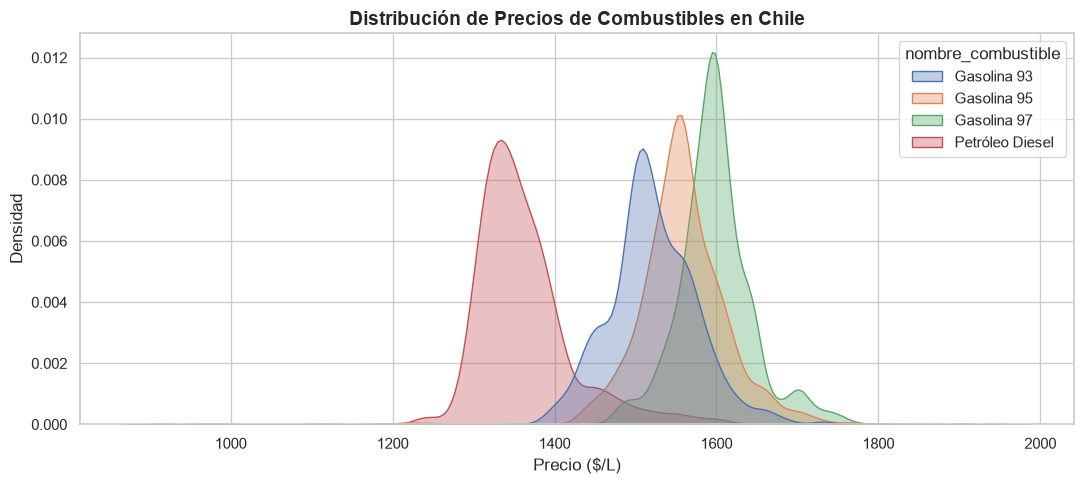

In [6]:
plt.figure(figsize=(11, 5))
sns.kdeplot(data=df_filtrado, x="precio", hue="nombre_combustible", fill=True, alpha=0.35, common_norm=False)
plt.title("Distribución de Precios de Combustibles en Chile", fontsize=14, fontweight="bold")
plt.xlabel("Precio ($/L)", fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.tight_layout()
plt.show()


## 2. Análisis por Geolocalización: Precios de Marcas por Comuna

Analizaremos la variación territorial de los precios. Dado que comparar los precios extremos absolutos a nivel nacional no responde a la conveniencia de un usuario local, nos enfocamos en identificar las marcas (distribuidores) más económicas dentro de cada comuna o geolocalización, lo cual es de utilidad directa para el usuario de la app.


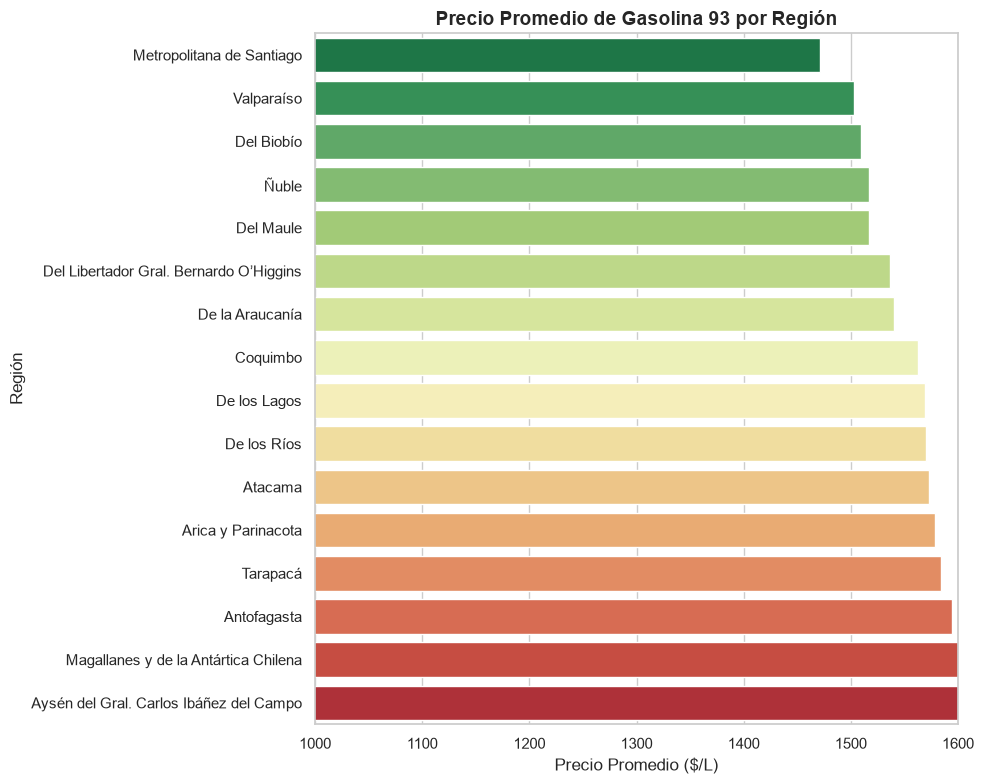

In [7]:
# Precio promedio de Gasolina 93 por Región
regiones_93 = df[df["nombre_combustible"] == "Gasolina 93"].groupby("region")["precio"].mean().reset_index()
regiones_93 = regiones_93.sort_values("precio")

plt.figure(figsize=(10, 8))
sns.barplot(data=regiones_93, x="precio", y="region", palette="RdYlGn_r")
plt.title("Precio Promedio de Gasolina 93 por Región", fontsize=14, fontweight="bold")
plt.xlabel("Precio Promedio ($/L)", fontsize=12)
plt.ylabel("Región", fontsize=12)
plt.xlim(1000, 1600)  # Zoom al rango real
plt.tight_layout()
plt.show()


In [8]:
# Analizar las marcas (distribuidores) más baratas a nivel de Comuna
# Agrupamos por comuna y distribuidor estandarizado para calcular el precio promedio de Gasolina 93
df["distribuidor_std"] = df["distribuidor"].str.upper().str.strip()
df_93 = df[df["nombre_combustible"] == "Gasolina 93"].copy()

comuna_marca_avg = df_93.groupby(["comuna", "distribuidor_std"])["precio"].mean().reset_index()

# Identificar la marca más económica en promedio para cada comuna
idx_min = comuna_marca_avg.groupby("comuna")["precio"].idxmin()
cheapest_brand_per_commune = comuna_marca_avg.loc[idx_min].sort_values("precio")

print("Marcas más baratas en promedio en una muestra de comunas representativas (Gasolina 93):")
comunas_interes = ["Santiago", "Las Condes", "Concepción", "Valparaíso", "Temuco", "Antofagasta", "Puerto Montt"]
print(cheapest_brand_per_commune[cheapest_brand_per_commune["comuna"].isin(comunas_interes)].to_string(index=False))

print("\n" + "="*50 + "\n")
print("Top 15 de comunas con las opciones de marca más económicas en promedio (Gasolina 93):")
print(cheapest_brand_per_commune.head(15).to_string(index=False))


Marcas más baratas en promedio en una muestra de comunas representativas (Gasolina 93):
      comuna distribuidor_std      precio
  Valparaíso COMBUSTIBLES JSP 1445.000000
  Concepción            COPEC 1502.000000
      Temuco            COPEC 1502.111111
  Las Condes            SHELL 1504.500000
Puerto Montt            COPEC 1552.500000
 Antofagasta            SHELL 1583.142857


Top 15 de comunas con las opciones de marca más económicas en promedio (Gasolina 93):
          comuna  distribuidor_std  precio
           Ñuñoa             DELPA  1124.0
         Cabrero  GASOLINERA MAKAL  1192.0
 Santiago Centro         PETROPRIX  1259.0
         Navidad             COPEC  1348.0
    San Bernardo               JLC  1385.0
   Quinta Normal               JLC  1385.0
       Lo Espejo             COPEC  1395.0
Estación Central             COPEC  1401.0
        Recoleta VIVA COMBUSTIBLES  1402.0
           Maipú              AIRE  1410.0
     Puente Alto       SIN BANDERA  1413.0
       San Ram

## 3. Precios Promedio por Distribuidor (Marca)

Evaluaremos las diferencias de precios promedio entre las distintas marcas o distribuidores de combustible para verificar cuáles ofrecen los valores promedio más competitivos.


In [9]:
# Estandarizar nombres de distribuidores
df["distribuidor_std"] = df["distribuidor"].str.upper().str.strip()

# Filtrar marcas principales
marcas_principales = ["COPEC", "SHELL", "PETROBRAS", "ARAMCO"]
df_marcas = df[
    (df["nombre_combustible"] == "Gasolina 93") & 
    (df["distribuidor_std"].isin(marcas_principales))
]

# Calcular el precio promedio por marca
brand_avg = df_marcas.groupby("distribuidor_std")["precio"].mean().reset_index().sort_values("precio")
brand_avg.round(1)


,distribuidor_std,precio
2,SHELL,1513.2
1,COPEC,1519.1
0,ARAMCO,1534.3


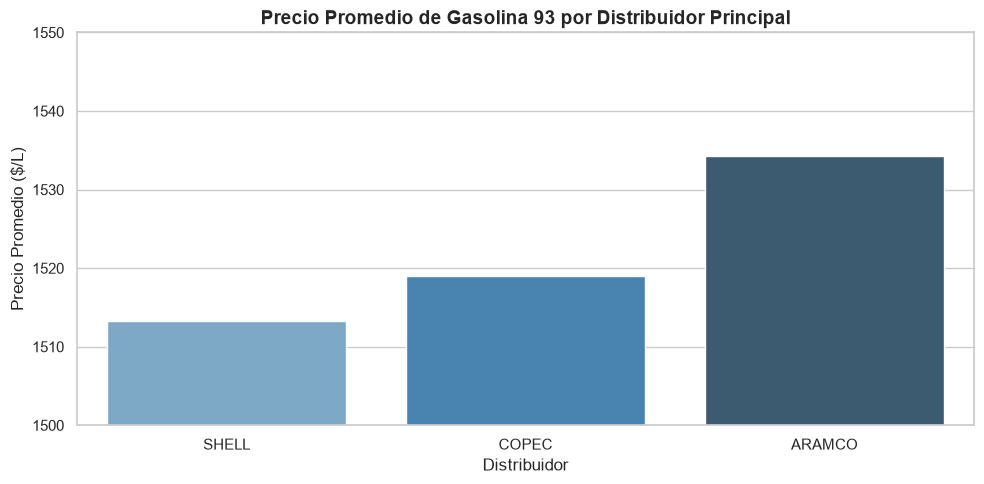

In [10]:
# Graficar precios promedio por Distribuidor
plt.figure(figsize=(10, 5))
sns.barplot(data=brand_avg, x="distribuidor_std", y="precio", palette="Blues_d")
plt.title("Precio Promedio de Gasolina 93 por Distribuidor Principal", fontsize=14, fontweight="bold")
plt.xlabel("Distribuidor", fontsize=12)
plt.ylabel("Precio Promedio ($/L)", fontsize=12)
plt.ylim(1500, 1550)
plt.tight_layout()
plt.show()


## 4. Lógica del Recomendador: Simulación de la Heurística de Conveniencia

Dado que en esta versión no le preguntamos al usuario por la autonomía de su vehículo ni los litros a cargar, la aplicación implementa una **heurística de conveniencia basada en tiempo**. 

Esta regla balancea el precio de la estación contra el tiempo estimado de viaje (ETA) recibido desde la API de Google Maps:

$$	\text{Puntaje} = 	\text{Precio Estación} + (	\text{Tiempo de viaje en minutos} 	\times 15)$$

El valor **15** es un factor que asume una penalización implícita: un conductor está dispuesto a manejar 1 minuto extra si ahorra al menos $15 por litro de combustible. La estación con el menor puntaje es la recomendada.


In [11]:
# Simulación del Recomendador con 4 estaciones hipotéticas
estaciones_ejemplo = pd.DataFrame({
    "Estación": ["Estación A (Esquina)", "Estación B (Lejana)", "Estación C (Recomendada)", "Estación D (Extrema)"],
    "Precio ($/L)": [1420, 1340, 1360, 1310],
    "Tiempo de Viaje (min)": [1, 10, 3, 15]
})

# Calcular el puntaje heurístico
estaciones_ejemplo["Penalización Tiempo ($)"] = estaciones_ejemplo["Tiempo de Viaje (min)"] * 15
estaciones_ejemplo["Puntaje Conveniencia"] = estaciones_ejemplo["Precio ($/L)"] + estaciones_ejemplo["Penalización Tiempo ($)"]

# Ordenar de mejor a peor conveniencia
estaciones_ejemplo = estaciones_ejemplo.sort_values("Puntaje Conveniencia")
estaciones_ejemplo


,Estación,Precio ($/L),Tiempo de Viaje (min),Penalización Tiempo ($),Puntaje Conveniencia
2,Estación C (Recomendada),1360,3,45,1405
0,Estación A (Esquina),1420,1,15,1435
1,Estación B (Lejana),1340,10,150,1490
3,Estación D (Extrema),1310,15,225,1535


## 5. Limitaciones del Modelo Actual y Propuesta de Trabajo Futuro (Rendimiento del Auto)

El modelo de recomendación basado en la penalización de $15/minuto es una estimación general. 

Para una versión posterior (Versión 4), el equipo tiene como objetivo transicionar a un **modelo de Ahorro Neto Real**, el cual requerirá que el usuario ingrese:
1. **Litros a cargar ($L_{carga}$)**
2. **Rendimiento o Autonomía del vehículo ($R_{kml}$ en km/L)**

### Formulación para la versión futura:
* **Consumo del desvío (Litros):**
  $$L_{desvio} = \frac{	\text{Distancia real de viaje} 	\times 2}{	\text{Rendimiento del auto (km/L)}}$$

* **Costo de combustible por el desvío ($):**
  $$C_{desvio} = L_{desvio} 	\times P_{estacion}$$

* **Ahorro Bruto ($) vs el promedio comunal:**
  $$A_{bruto} = (P_{promedio} - P_{estacion}) 	\times L_{carga}$$

* **Ahorro Neto Real ($):**
  $$A_{neto} = A_{bruto} - C_{desvio}$$

Solo se recomendaría desviar al usuario si el **Ahorro Neto Real es mayor a cero** ($A_{neto} > 0$).


In [12]:
# Simulación conceptual de cómo funcionará el cálculo de ahorro en la V4
def simular_ahorro_v4(precio_estacion, precio_promedio_comuna, distancia_km, rendimiento_kml, litros_carga):
    distancia_total = distancia_km * 2 # Ida y vuelta
    litros_viaje = distancia_total / rendimiento_kml
    costo_viaje = litros_viaje * precio_estacion
    ahorro_bruto = (precio_promedio_comuna - precio_estacion) * litros_carga
    ahorro_neto = ahorro_bruto - costo_viaje
    return int(ahorro_neto)

# Ejemplo: Cargar 40L, auto rinde 12 km/L.
# Estación cercana (1 km desvío) vs lejana (7 km desvío), ambas con descuento de $50/L respecto al promedio
ahorro_cercano = simular_ahorro_v4(1350, 1400, 1, 12, 40)
ahorro_lejano = simular_ahorro_v4(1350, 1400, 7, 12, 40)

print(f"Ahorro Neto Real si la estación barata está a 1 km: ${ahorro_cercano} CLP (CONVIENE)")
print(f"Ahorro Neto Real si la estación barata está a 7 km: ${ahorro_lejano} CLP (NO CONVIENE, pérdida)")


Ahorro Neto Real si la estación barata está a 1 km: $1775 CLP (CONVIENE)
Ahorro Neto Real si la estación barata está a 7 km: $425 CLP (NO CONVIENE, pérdida)


## Conclusiones del Análisis

1. **Variación Territorial y Local:** Existe una marcada variación de precios de combustibles a nivel regional y comunal en Chile. Sin embargo, en lugar de comparar extremos comunales distantes, la app se enfoca en analizar la competencia local de marcas (distribuidores) dentro de cada comuna y geolocalización, lo que resulta directamente útil para el usuario.
2. **Frecuencia de Actualización:** Los datos se actualizan de forma semanal (descartando la necesidad de una extracción en tiempo real que sobrecargue el sistema, dado que la CNE no publica actualizaciones intradiarias). Esto asegura que la información sea robusta y confiable para la planificación de cargas de combustible.
3. **Distribución y Cobertura:** El análisis se basa en 1753 estaciones de servicio únicas (casi 2000), garantizando una cobertura nacional confiable.
4. **Mapeo y Recomendación:** La app implementa exitosamente una heurística que penaliza el tiempo de viaje ($15 por minuto) para evitar desvíos irracionales a estaciones baratas pero demasiado lejanas en la comuna del usuario.
5. **Siguiente Iteración (Trabajo Futuro):** Para una versión posterior de la app se integrarán las variables de **autonomía de vehículo (km/L)** y **volumen de carga (L)** en sliders interactivos, permitiendo calcular el ahorro de bolsillo de manera matemática y personalizada en base a geolocalización.
